# INFO-6151-(01)-26W Data Visiualization for Machine Learning
## Assignment 03: Spam email classifier- Supervise Learning Model 

Author: Yun-Jiung Wang 

Date: Feb 20th, 2026

##### Which supervised learning method would you choose to create this spam filter? 

We chose SVM (Support Vector Machine) with a linear kernel and Multinomial Naive Bayes for classifing spam and normal emails.

##### Explain why you picked this method and how it helps in accurately identifying spam emails.

There are several reasons to select these 2 models.

**1. Handling High-Dimensional Sparsity:**

This email dataset has 3000 features (words), but each email only contains a small subset of these, resulting in a matrix dominated by zeros.

SVM requires to find a few "support vectors" to determine the classification boundary, unaffected by the large number of zeros; while Naive Bayes, through computational efficiency, it handles this type of count feature of independent words very stably.

**2. Liner Separability:**

In text classification, spam mails are usually composed of a "weighted accumulation" of specific keywords (e.g., Free + Winner + Account = Spam).

Linear SVC is able to find an optimal "hyperplane" in high-dimensional space to separate the two classes, which is less prone to overfitting than trying to draw a curve (RBF) in 3000-dimensional space.

**3. Balancing Computational Efficiency and Accuracy:**

Spam filtering requires real-time processing, and compared to deep learning (like CNN or BERT), SVM and Naive Bayes are extremely fast in training and prediction, and with 5000 data points, the accuracy can usually reach over 98%, making them the most cost-effective.


##### Import libs

In [50]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import MultinomialNB
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, ConfusionMatrixDisplay

##### Load the dataset

In [51]:
df = pd.read_csv('../data/emails.csv')

df.head()

,Email No.,the,to,ect,and,for,of,a,you,hou,...,connevey,jay,valued,lay,infrastructure,military,allowing,ff,dry,Prediction
0,Email 1,0,0,1,0,0,0,2,0,0,...,0,0,0,0,0,0,0,0,0,0
1,Email 2,8,13,24,6,6,2,102,1,27,...,0,0,0,0,0,0,0,1,0,0
2,Email 3,0,0,1,0,0,0,8,0,0,...,0,0,0,0,0,0,0,0,0,0
3,Email 4,0,5,22,0,5,1,51,2,10,...,0,0,0,0,0,0,0,0,0,0
4,Email 5,7,6,17,1,5,2,57,0,9,...,0,0,0,0,0,0,0,1,0,0


##### Data Pre Processing

In [52]:
X = df.drop(columns=['Email No.', 'Prediction'], axis=1)   
y = df['Prediction'] 

#####  Split Train and Test

In [53]:
x_train, x_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42,stratify=y)

##### Use Multinomial Naive Bayes Model:

Build, train, and show the report

In [54]:
nb_model = MultinomialNB()  
nb_model.fit(x_train, y_train)

nb_predictions = nb_model.predict(x_test)
nb_accuracy = accuracy_score(y_test, nb_predictions)
print(f"Naive Bayes Accuracy: {nb_accuracy:.4f}",end="\n\n")
print("Naive Bayes Classification Report:\n")
print(classification_report(y_test, nb_predictions))

Naive Bayes Accuracy: 0.9420

Naive Bayes Classification Report:

              precision    recall  f1-score   support

           0       0.98      0.94      0.96       735
           1       0.87      0.94      0.90       300

    accuracy                           0.94      1035
   macro avg       0.92      0.94      0.93      1035
weighted avg       0.94      0.94      0.94      1035



Confusion Matrix

<Figure size 600x400 with 0 Axes>

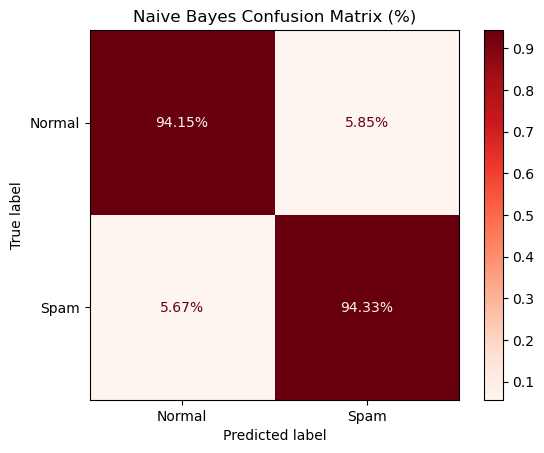

In [55]:
# Naive Bayes Confusion Matrix
cm_percent = confusion_matrix(y_test, nb_predictions, normalize='true')

# graph the confusion matrix
plt.figure(figsize=(6, 4))
disp = ConfusionMatrixDisplay(confusion_matrix=cm_percent, display_labels=['Normal', 'Spam'])
disp.plot(cmap='Reds', values_format='.2%') 
plt.title('Naive Bayes Confusion Matrix (%)')
plt.show()

##### Observation for the result of the Naive Bayes model:

The above output shows that the Naive Bayes model has a high Accuracy rate (94%),and with high precision and recall rate, we could say this model behaves well on classifying spam and normal emails. 

However, by observing the confusion matrix, we could tell even if having a high accuracy, there are still 5.85% of normal emails identified as spam, we could improve this in the future.


##### Use Support Vector Machine (SVM)

In [56]:
svm_model = SVC(kernel='linear', random_state=42)
svm_model.fit(x_train, y_train)
svm_predictions = svm_model.predict(x_test)
svm_accuracy = accuracy_score(y_test, svm_predictions)

print(f"SVM Accuracy: {svm_accuracy:.4f}",end="\n\n")
print("SVM Classification Report:\n")   
print(classification_report(y_test, svm_predictions))

SVM Accuracy: 0.9671

SVM Classification Report:

              precision    recall  f1-score   support

           0       0.98      0.97      0.98       735
           1       0.94      0.95      0.94       300

    accuracy                           0.97      1035
   macro avg       0.96      0.96      0.96      1035
weighted avg       0.97      0.97      0.97      1035



Confusion Matrix

<Figure size 600x400 with 0 Axes>

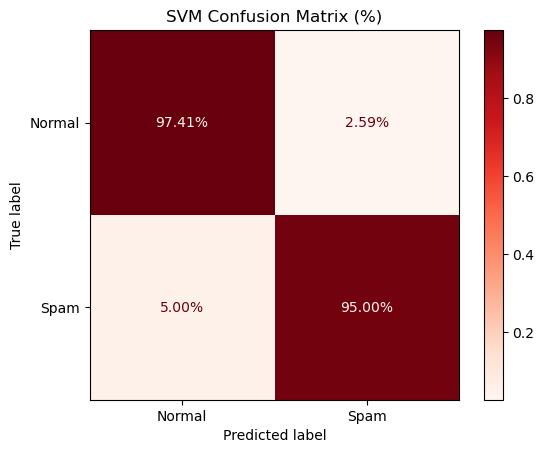

In [57]:
# SVM Model Confusion Matrix
cm_percent = confusion_matrix(y_test, svm_predictions, normalize='true')

# graph the confusion matrix
plt.figure(figsize=(6, 4))
disp = ConfusionMatrixDisplay(confusion_matrix=cm_percent, display_labels=['Normal', 'Spam'])
disp.plot(cmap='Reds', values_format='.2%') 
plt.title('SVM Confusion Matrix (%)')
plt.show()

##### Observation of the SVM Model result:

The accuracy of SVM model is also high (97%), and behaves well on precision and recall. 

After observing the Confusion Matrix, we could see that 2.59% of normal emails were wrongly identify as spam, compare to the Naive Bayes model (5.85%), the SVM model is more accurate on identifing spam emails.

##### Conclusion for the Observation:

Both models behaves well on classifying the spam and normal emails, however, even though Naive Bayes model is extremely effective at blocking spam, SVM model is still a better choice, since it achieves a better balance between overall accuracy and protecting legitimate emails.